# Setup

## Libraries

In [1]:
# Regular expressions (re)
import re
# NumPy, pandas, matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Scipy
import scipy.stats as stats
from scipy.stats import mannwhitneyu
# PyCaret
from pycaret.classification import *
# SciKit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [2]:
# Japanize Matplotlib
import japanize_matplotlib
%matplotlib inline

# Prepare Dataset 

## Load Data

In [3]:
filename = '../Results/output02.csv'
df = pd.read_csv(filename, header=0, index_col=0)
df.head()

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_cosine,Adj_euclidean,Adj_manhattan,Verb_cosine,Verb_euclidean,Verb_manhattan,Noun_cosine,Noun_euclidean,Noun_manhattan
MID,,,,,,,,,,,,,,,,
2,193.0,1,45,3,2,5,HighIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,137.0,1,36,4,2,2,LowIOS,NaN,NaN,NaN,0.933851,0.344139,1.932724,0.882830,0.469692,2.609289
7,293.0,1,54,1,2,5,HighIOS,0.489526,0.77925,4.465907,0.826740,0.433577,2.556113,0.035336,1.129285,6.480907
8,103.0,1,36,1,2,1,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,0.397660,1.097579,6.200497
11,160.0,1,56,1,2,2,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Missing Values

## Proportion of missing data

In [4]:
# The number of rows in the df_cosine
num_rows = len(df)
# The number of rows with missing value(s)
num_rows_nan = df.isnull().any(axis=1).sum()
# The percentage of rows with missing value(s)
percentage_rows_nan = num_rows_nan / num_rows * 100
# Print
print(f"Number of rows: {num_rows}")
print(f"Number of rows with missing value(s): {num_rows_nan}")
print(f"Percentage of missing data: {percentage_rows_nan}")

Number of rows: 403
Number of rows with missing value(s): 222
Percentage of missing data: 55.08684863523573


In [5]:
# Add a new columne to the df_cosine dataframe to indicate the missing values
df['missing'] = df.isnull().any(axis=1)

## Independency: Missing vs. IOS group (High vs. Low)

In [6]:
# Compare the number of the occurrences of the missing values with respect to the 'IOS_group' column
crosstab_iosgroup = pd.crosstab(df['missing'], df['IOS_group'])
crosstab_iosgroup

IOS_group,HighIOS,LowIOS
missing,,
False,83,98
True,120,102


In [7]:
# Chi-square test of independence for the 'IOS_group' and 'missing' columns
chi2, p, dof, expected = stats.chi2_contingency(crosstab_iosgroup)
print(f"Chi2: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 2.3624731417555056
p-value: 0.12428501348019987
Degrees of freedom: 1


## Independency: Missing vs. IOS scores

In [8]:
crosstab_iosscore = pd.crosstab(df['missing'], df['IOS_score'])
crosstab_iosscore

IOS_score,1,2,3,5,6,7
missing,,,,,,
False,33,35,30,24,32,27
True,32,40,30,41,40,39


In [9]:
# Chi-square test of independence for the 'IOS_score' and 'missing' columns
chi2, p, dof, expected = stats.chi2_contingency(crosstab_iosscore)
print(f"Chi2: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 3.7330010824485966
p-value: 0.5884606613799822
Degrees of freedom: 5


## Independency: Missing vs. Self_Sex

In [10]:
# Crosstab with the missing values and the 'self_sex' column
crosstab_self_sex = pd.crosstab(df['missing'], df['self_sex'])
crosstab_self_sex

self_sex,1,2,4
missing,,,
False,94,87,0
True,121,98,3


In [11]:
# Chi-square test of independence for the 'self_sex'
chi2, p, dof, expected = stats.chi2_contingency(crosstab_self_sex)
print(f"Chi2: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")

Chi2: 2.903589190866036
p-value: 0.23414970682555047
Degrees of freedom: 2


## Missing vs. Not-Missing: Self-age

In [12]:
# The descriptive statistics of the 'self_age' column with respect to the 'missing' column, grouped by the 'IOS_group' and 'self_sex' columns
df.groupby(['missing'])['self_age'].describe()

,count,mean,std,min,25%,50%,75%,max
missing,,,,,,,,
False,181.0,48.397790,8.464094,24.0,43.0,50.0,55.0,59.0
True,222.0,46.702703,9.131116,21.0,40.0,49.0,54.0,59.0


In [13]:
# Extract self_age for missing and not-missing groups
self_age_missing = df[df['missing']]['self_age']
self_age_not_missing = df[~df['missing']]['self_age']

# Perform the Mann-Whitney U test
stat, p = mannwhitneyu(self_age_missing, self_age_not_missing)

# Print the result
print(f'Mann-Whitney U test statistic: {stat}, p-value: {p}')

# Interpret the p-value
alpha = 0.05  # Typical threshold of significance
if p > alpha:
    print('No significant difference between HighIOS and LowIOS groups (fail to reject H0)')
else:
    print('Significant difference between HighIOS and LowIOS groups (reject H0)')

Mann-Whitney U test statistic: 17958.0, p-value: 0.06649310919551593
No significant difference between HighIOS and LowIOS groups (fail to reject H0)


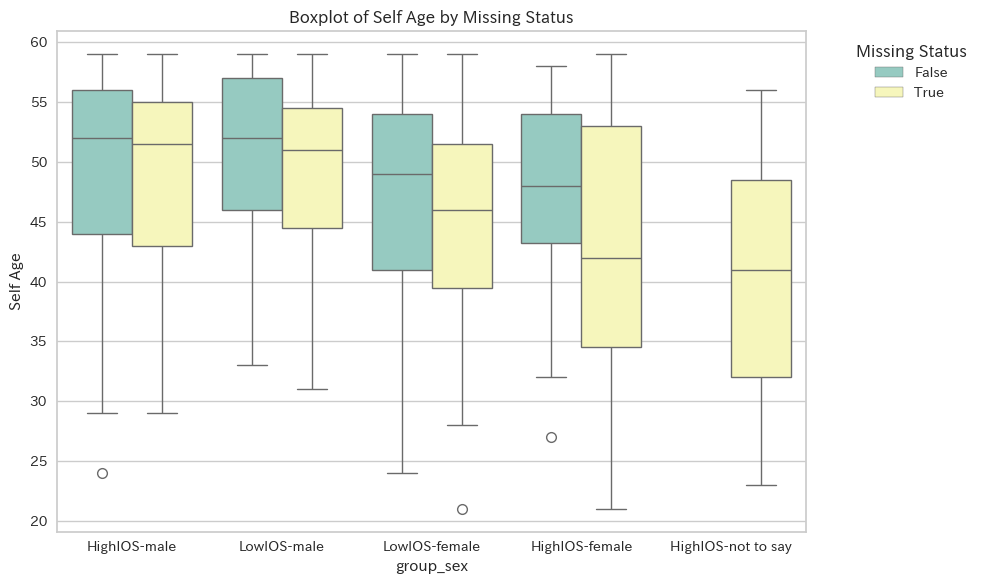

In [14]:
# Step 1: Combine Columns
df['self_sex_str'] = df['self_sex'].map({1: 'male', 2: 'female', 4: 'not to say'})
df['group_sex'] = df['IOS_group'] + '-' + df['self_sex_str']
# Step 2: Create the Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group_sex', y='self_age', hue='missing', data=df, palette="Set3")
# Step 3: Customize the Plot
plt.title('Boxplot of Self Age by Missing Status')
plt.ylabel('Self Age')
plt.legend(title='Missing Status', bbox_to_anchor=(1.05, 1), loc='upper left')
# Step 4: Show the Plot
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()

## Missing vs. Not-missing: RT

In [15]:
df.groupby(['missing'])['rt'].describe()

,count,mean,std,min,25%,50%,75%,max
missing,,,,,,,,
False,181.0,1517.176796,7411.674762,106.0,286.0,443.0,745.00,89172.0
True,222.0,2084.459459,16445.901107,76.0,156.5,227.0,364.75,227706.0


In [16]:
# Assuming df is your DataFrame and it has 'group' and 'IOS_score' columns
# Extract IOS_score for HighIOS and LowIOS groups
rt_missing = df[df['missing']]['rt']
rt_not_missing = df[~df['missing']]['rt']

# Perform the Mann-Whitney U test
stat, p = mannwhitneyu(rt_missing, rt_not_missing)

# Print the result
print(f'Mann-Whitney U test statistic: {stat}, p-value: {p}')

# Interpret the p-value
alpha = 0.05  # Typical threshold of significance
if p > alpha:
    print('No significant difference between HighIOS and LowIOS groups (fail to reject H0)')
else:
    print('Significant difference between HighIOS and LowIOS groups (reject H0)')

Mann-Whitney U test statistic: 9866.5, p-value: 1.4903023071326314e-18
Significant difference between HighIOS and LowIOS groups (reject H0)


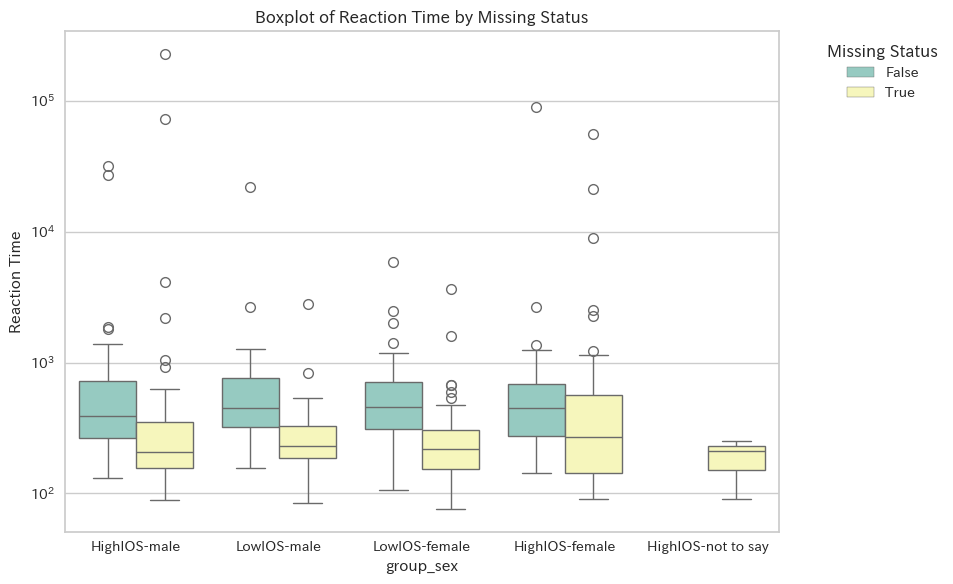

In [17]:
# Step 2: Create the Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='group_sex', y='rt', hue='missing', data=df, palette="Set3")
# Step 3: Customize the Plot
plt.title('Boxplot of Reaction Time by Missing Status')
plt.ylabel('Reaction Time')
plt.legend(title='Missing Status', bbox_to_anchor=(1.05, 1), loc='upper left')
# Step 4: Show the Plot
plt.tight_layout()  # Adjust layout to make room for the legend
plt.yscale('log')
plt.show()

## Remove the Missing Values

In [18]:
df_roi = df.dropna()
print(f"The number of the ramaining observations: {len(df_roi)}")

The number of the ramaining observations: 181


# Inspect Dataset

## Demographic Information

In [19]:
# The descriptive statistics of self_age with respect to the IOS_group and self_sex
df_roi.groupby(['IOS_group', 'self_sex'])['self_age'].describe()

count       mean       std   min    25%   50%   75%   max
IOS_group self_sex                                                           
HighIOS   1          45.0  49.022222  8.817567  24.0  44.00  52.0  56.0  59.0
          2          38.0  47.078947  8.234343  27.0  43.25  48.0  54.0  58.0
LowIOS    1          49.0  50.489796  7.243165  33.0  46.00  52.0  57.0  59.0
          2          49.0  46.755102  9.148157  24.0  41.00  49.0  54.0  59.0

## Completion Time

           count         mean           std    min     25%    50%     75%  \
IOS_group                                                                   
HighIOS     83.0  2298.566265  10644.594135  132.0  266.00  434.0  714.50   
LowIOS      98.0   855.387755   2277.461906  106.0  309.75  451.5  752.75   

               max  
IOS_group           
HighIOS    89172.0  
LowIOS     22147.0  


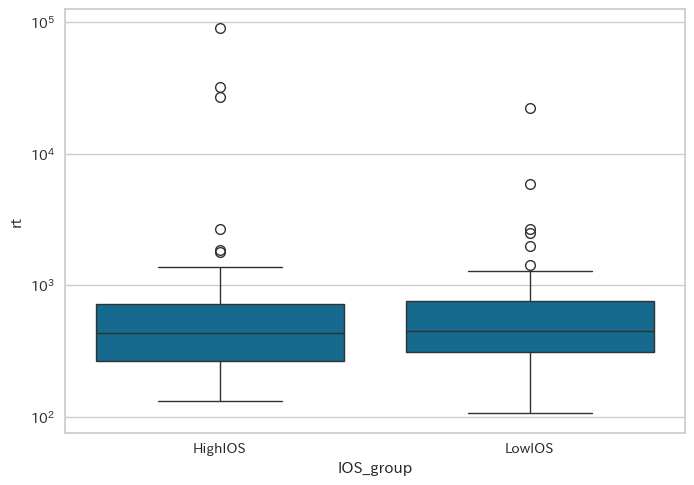

In [20]:
# The descriptive statistics of rt with respect to IOS_group
print(df_roi.groupby('IOS_group')['rt'].describe())
# The boxplot of rt with respect to IOS_group
sns.boxplot(x='IOS_group', y='rt', data=df_roi, order=['HighIOS', 'LowIOS'])
plt.yscale('log')
plt.show()

In [21]:
# Mann-Whitney U test for the rt column with respect to the IOS_group
rt_highios = df_roi[df_roi['IOS_group'] == 'HighIOS']['rt']
rt_lowios = df_roi[df_roi['IOS_group'] == 'LowIOS']['rt']
mannwhitneyu(rt_highios, rt_lowios)

MannwhitneyuResult(statistic=3622.5, pvalue=0.2061847373433765)

In [22]:
# T-test for the rt column with respect to the IOS_group
# t_stat, p = stats.ttest_ind(rt_highios, rt_lowios)
# print(f'T-test statistic: {t_stat}, p-value: {p}')
stats.ttest_ind(rt_highios, rt_lowios)

TtestResult(statistic=1.3078924628454178, pvalue=0.19258695825060834, df=179.0)

# Preprocessing: Setup()

In [23]:
df_roi = df_roi.drop(columns=['IOS_score', 'missing', 'self_sex_str', 'group_sex'])

In [24]:
df_roi.head()

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_group,Adj_cosine,Adj_euclidean,Adj_manhattan,Verb_cosine,Verb_euclidean,Verb_manhattan,Noun_cosine,Noun_euclidean,Noun_manhattan
MID,,,,,,,,,,,,,,,
7,293.0,1,54,1,2,HighIOS,0.489526,0.779250,4.465907,0.826740,0.433577,2.556113,0.035336,1.129285,6.480907
47,286.0,2,49,1,2,LowIOS,0.343798,0.909868,5.381318,0.767628,0.551194,3.338891,0.868594,0.384930,2.128364
64,454.0,2,47,2,1,LowIOS,0.580847,0.823228,4.458152,0.837091,0.371915,2.131163,0.656584,0.550191,2.960705
66,457.0,2,55,2,1,HighIOS,0.557176,0.800420,4.400890,0.751485,0.457288,2.585123,0.622296,0.566173,3.115598
78,175.0,2,42,4,1,LowIOS,0.720062,0.538742,2.846106,0.695203,0.529330,2.867493,0.480041,0.548655,3.126720


In [25]:
df_roi.shape

(181, 15)

In [26]:
# Count the number of values in the 'IOS_group' column
df_roi['IOS_group'].value_counts()

IOS_group
LowIOS     98
HighIOS    83
Name: count, dtype: int64

In [27]:
# Unique values in the 'self_sex' column
df_roi['self_sex'].unique()

array([1, 2])

In [28]:
# Unique values in the 'target_sex' column
df_roi['target_sex'].unique()

array([2, 1, 4])

In [29]:
# Unique values in the 'target_likedislile' column
df_roi['target_likedislike'].unique()

array([1, 2, 4, 3, 6, 5])

In [30]:
# Remove rows with values other than 1 and 2 in the 'target_sex' column
df_roi = df_roi[df_roi['target_sex'].isin([1, 2])]
# Unique values
df_roi['target_sex'].unique()

array([2, 1])

In [31]:
# Count the number of values in the 'IOS_group' column
df_roi['IOS_group'].value_counts()

IOS_group
LowIOS     95
HighIOS    82
Name: count, dtype: int64

## Setup for PyCaret

In [32]:
exp = setup(data=df_roi,
            target='IOS_group',
            session_id=123,
            categorical_features=['self_sex', 'target_sex'],
            ordinal_features={'target_likedislike': [1, 2, 3, 4, 5]},
            ignore_features=['rt'],
            imputation_type='simple',
            fix_imbalance=True,
            fix_imbalance_method='smote',
            normalize=True,
            normalize_method='zscore',
            feature_selection=False,
            remove_multicollinearity=True,
            multicollinearity_threshold=0.95,
            )

,Description,Value
0,Session id,123
1,Target,IOS_group
2,Target type,Binary
3,Target mapping,"HighIOS: 0, LowIOS: 1"
4,Original data shape,"(177, 15)"
5,Transformed data shape,"(186, 11)"
6,Transformed train set shape,"(132, 11)"
7,Transformed test set shape,"(54, 11)"
8,Ignore features,1
9,Ordinal features,1


In [33]:
exp.X_transformed.sort_index()

,self_sex,self_age,target_likedislike,target_sex,Adj_cosine,Adj_manhattan,Verb_cosine,Verb_euclidean,Noun_cosine,Noun_manhattan
7,-0.957416,0.743832,-1.237521,0.927784,-0.849063,0.682570,0.538811,-0.190006,-3.116941,2.672163
47,1.075324,0.175821,-1.237521,0.927784,-1.608286,1.380175,0.228922,0.311130,1.097395,-0.815584
64,1.075324,-0.051383,-0.536173,-1.102595,-0.373295,0.676660,0.593075,-0.452727,0.025119,-0.148618
66,1.075324,0.857434,-0.536173,-1.102595,-0.496613,0.633022,0.144294,-0.088979,-0.148297,-0.024501
78,1.075324,-0.619394,0.866522,-1.102595,0.351998,-0.551827,-0.150755,0.217971,-0.867773,-0.015589
...,...,...,...,...,...,...,...,...,...,...
925,-0.957416,0.857434,-0.156112,-1.102595,0.321338,-0.422259,0.580427,-0.635373,-0.289999,-0.001502
926,-0.957416,-2.345336,-1.237521,0.037316,-0.189743,0.116993,-0.312835,0.057563,-1.269204,1.198382
927,-0.957416,-0.492233,-1.237521,0.927784,-0.188195,0.163337,0.176506,-0.234444,-0.582693,0.454002
928,-0.148295,0.152656,0.308187,0.119603,1.329261,-1.362491,1.291123,-1.659907,0.432176,-0.153602


In [34]:
exp.y.sort_index()

MID
7      HighIOS
47      LowIOS
64      LowIOS
66     HighIOS
78      LowIOS
        ...   
913    HighIOS
917    HighIOS
918    HighIOS
920    HighIOS
924    HighIOS
Name: IOS_group, Length: 177, dtype: category
Categories (2, object): ['HighIOS', 'LowIOS']

In [35]:
# Combine the transformed features and the target variable with respect to the index
combined_data = exp.X_transformed.join(exp.y, how='inner')
combined_data

,self_sex,self_age,target_likedislike,target_sex,Adj_cosine,Adj_manhattan,Verb_cosine,Verb_euclidean,Noun_cosine,Noun_manhattan,IOS_group
7,-0.957416,0.743832,-1.237521,0.927784,-0.849063,0.682570,0.538811,-0.190006,-3.116941,2.672163,HighIOS
47,1.075324,0.175821,-1.237521,0.927784,-1.608286,1.380175,0.228922,0.311130,1.097395,-0.815584,LowIOS
64,1.075324,-0.051383,-0.536173,-1.102595,-0.373295,0.676660,0.593075,-0.452727,0.025119,-0.148618,LowIOS
66,1.075324,0.857434,-0.536173,-1.102595,-0.496613,0.633022,0.144294,-0.088979,-0.148297,-0.024501,HighIOS
78,1.075324,-0.619394,0.866522,-1.102595,0.351998,-0.551827,-0.150755,0.217971,-0.867773,-0.015589,LowIOS
...,...,...,...,...,...,...,...,...,...,...,...
917,-0.957416,1.084638,1.567870,-1.102595,1.246432,-1.290253,0.818941,-0.325100,0.991101,-0.813285,HighIOS
918,1.075324,-0.619394,1.567870,0.927784,0.865832,-0.980458,0.665046,-0.906388,0.717721,-0.855618,HighIOS
920,1.075324,-0.505792,0.866522,-1.102595,0.832455,-0.902200,0.346501,0.255306,-0.872405,0.559034,HighIOS
924,-0.957416,-0.200616,-0.996834,0.927784,0.873690,-0.766554,1.071756,-0.192946,0.283146,-0.052483,HighIOS


<Figure size 1000x600 with 0 Axes>

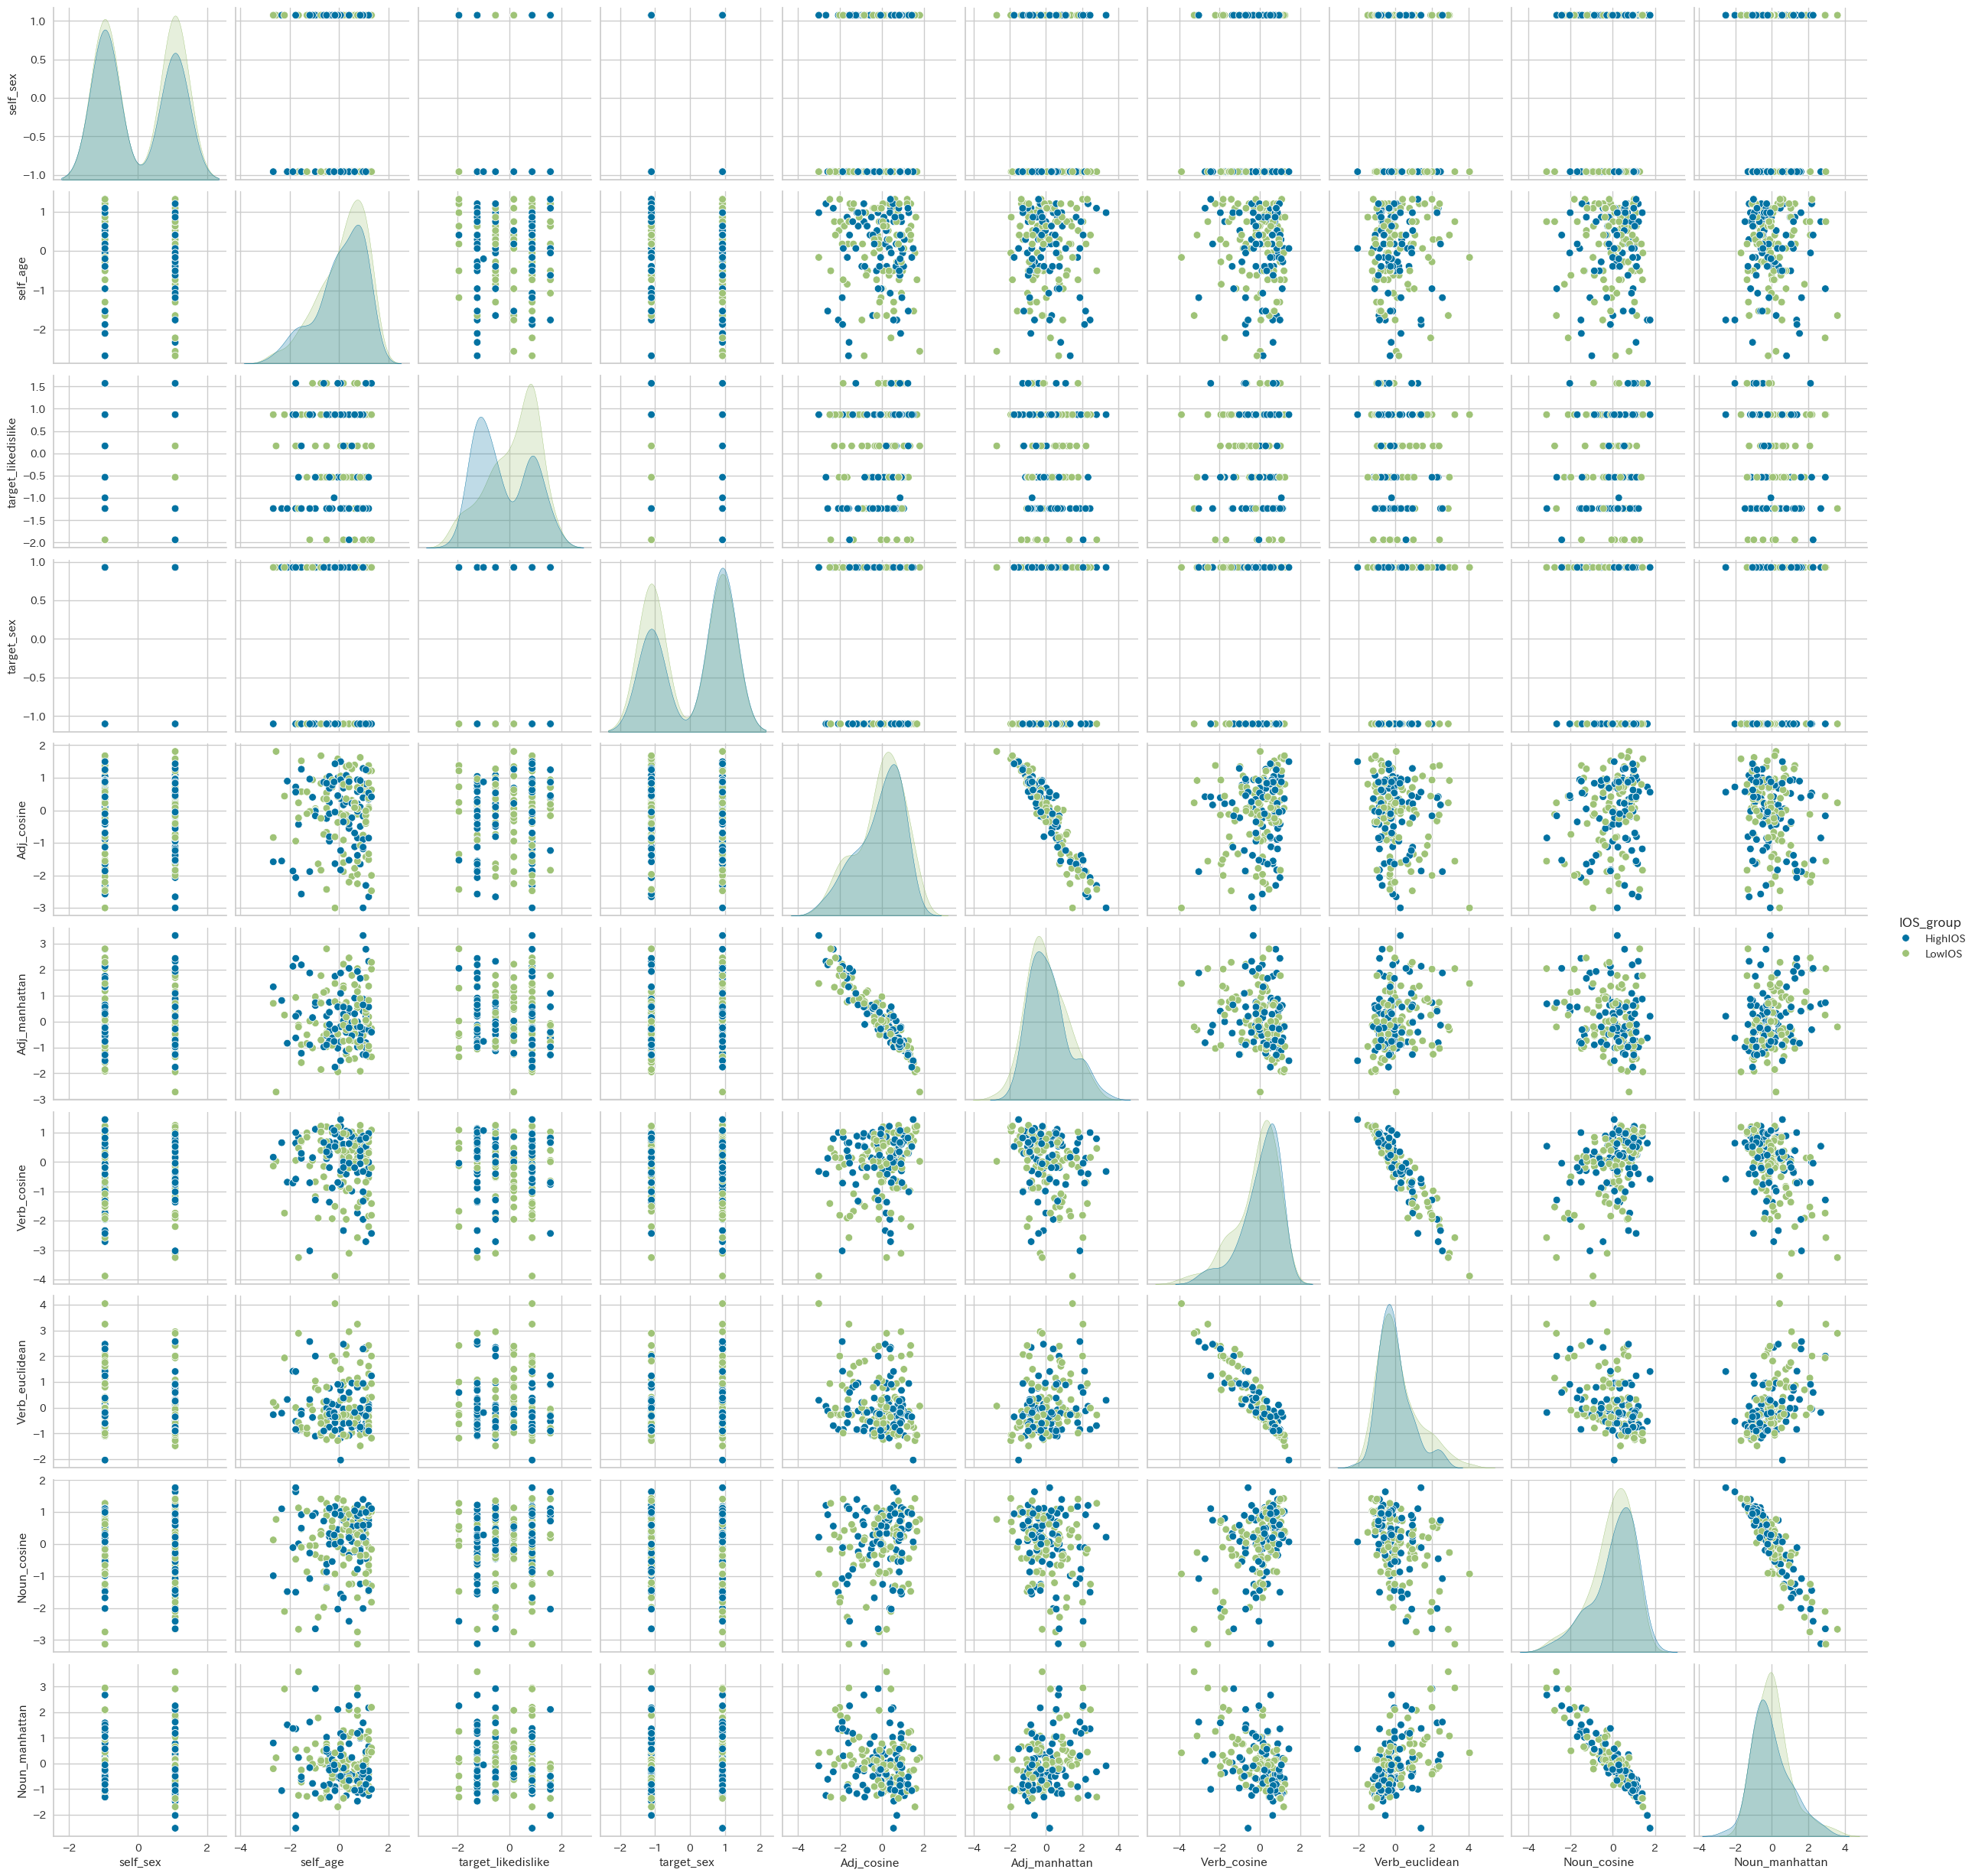

In [36]:
# Pairplot of the features in the dataset colored by the target
plt.figure(figsize=(10, 6))
sns.pairplot(data=combined_data, hue='IOS_group')
plt.show()

# Exploring Models

## Model Comparision

In [37]:
# Find the best model
best = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.6167,0.5952,0.6167,0.6315,0.6127,0.2381,0.2455,0.2690
ridge,Ridge Classifier,0.6006,0.5952,0.6006,0.6149,0.5960,0.2053,0.2122,0.0130
lda,Linear Discriminant Analysis,0.6006,0.5904,0.6006,0.6122,0.5950,0.2074,0.2107,0.0140
knn,K Neighbors Classifier,0.5718,0.5418,0.5718,0.5779,0.5608,0.1379,0.1416,0.1950
lightgbm,Light Gradient Boosting Machine,0.5519,0.5287,0.5519,0.5600,0.5413,0.0980,0.1039,1.4380
svm,SVM - Linear Kernel,0.5436,0.5683,0.5436,0.5463,0.5385,0.0789,0.0802,0.0130
et,Extra Trees Classifier,0.5378,0.5509,0.5378,0.5272,0.5248,0.0685,0.0577,0.0380
nb,Naive Bayes,0.5128,0.5062,0.5128,0.5254,0.4979,0.0446,0.0425,0.0130
gbc,Gradient Boosting Classifier,0.5115,0.5313,0.5115,0.5086,0.4956,0.0171,0.0129,0.0240
rf,Random Forest Classifier,0.4891,0.5225,0.4891,0.4903,0.4827,-0.0230,-0.0262,0.0440


In [38]:
# The model object
best

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [39]:
## get current date and time
#from datetime import datetime
#now = datetime.now()
## convert now to string
#now_str = now.strftime("%Y%m%d_%H%M")
#
## save the best model
#save_model(best, f'../models/best_model_pipeline_{now_str}Z')
#
## Print the file name
#print(f'best_model_pipeline_{now_str}Z')

In [40]:
# launch the evaluation widget
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…